In [ ]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
!apt-get install -y ffmpeg libsndfile1
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

In [ ]:
api.dataset_download_files(
    "andradaolteanu/gtzan-dataset-music-genre-classification",
    path="/content/dataset",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification


In [ ]:
import os

os.listdir("/content/dataset/Data")

['features_3_sec.csv',
 'images_original',
 'features_30_sec.csv',
 'genres_original']

In [ ]:
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
import numpy as np
import torch
import os
from torch.utils.data import Dataset


class GenreDataset(Dataset):

    def __init__(self, data_path, sr=22050, duration=3, augment=False):

        self.augment = augment
        self.data = []
        self.labels = []

        self.sr = sr
        self.samples = sr * duration

        genres = sorted(os.listdir(data_path))

        # label mapping
        self.genre_to_idx = {genre: i for i, genre in enumerate(genres)}
        self.idx_to_genre = {i: genre for genre, i in self.genre_to_idx.items()}

        for genre in genres:
            genre_folder = os.path.join(data_path, genre)

            for file in os.listdir(genre_folder):
                if file.endswith(".wav"):
                    file_path = os.path.join(genre_folder, file)
                    self.data.append(file_path)
                    self.labels.append(self.genre_to_idx[genre])

        # transforms
        self.mel_spectrogram_transform = T.MelSpectrogram(
            sample_rate=self.sr,
            n_fft=1024,
            hop_length=256,
            n_mels=128
        )

        self.amplitude_to_db_transform = T.AmplitudeToDB()

        # SpecAugment
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=35)


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):

        file_path = self.data[idx]
        label = self.labels[idx]

        try:
            audio, sr_original = torchaudio.load(file_path)

            # resample properly
            if sr_original != self.sr:
                resampler = T.Resample(sr_original, self.sr)
                audio = resampler(audio)

            # stereo → mono
            if audio.shape[0] > 1:
                audio = torch.mean(audio, dim=0, keepdim=True)

            # fixed length
            if audio.shape[1] > self.samples:
                audio = audio[:, :self.samples]
            else:
                padding = self.samples - audio.shape[1]
                audio = F.pad(audio, (0, padding))

            # waveform augmentation
            if self.augment:

                # time shift
                shift = np.random.randint(self.samples)
                audio = torch.roll(audio, shifts=shift, dims=1)

                # stronger noise
                audio += 0.005 * torch.randn_like(audio)

                # random gain
                gain = np.random.uniform(0.8, 1.2)
                audio = audio * gain

            # mel spectrogram
            mel = self.mel_spectrogram_transform(audio)
            mel = self.amplitude_to_db_transform(mel)

            if self.augment:
                mel = self.freq_mask(mel)
                mel = self.time_mask(mel)

            mel = (mel - mel.mean()) / (mel.std() + 1e-6)

            return mel, torch.tensor(label)

        except Exception:
            return self.__getitem__((idx + 1) % len(self.data))

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

path = "/content/dataset/Data/genres_original"


# Create ONE base dataset
base_dataset = GenreDataset(path, augment=False)

dataset_size = len(base_dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size


# Shuffle indices

indices = torch.randperm(dataset_size)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]


# Create subsets

train_dataset = Subset(base_dataset, train_indices)
val_dataset = Subset(base_dataset, val_indices)
test_dataset = Subset(base_dataset, test_indices)

# Enable augmentation ONLY for training
train_dataset.dataset.augment = True


# DataLoaders (optimized)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class GenreCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # Convolution Blocks
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)  # NEW
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2)

        # Adaptive pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.flat = nn.Flatten()

        # Fully Connected
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        # Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Conv Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)

        # Flatten
        x = self.flat(x)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(base_dataset.genre_to_idx)

model = GenreCNN(num_classes).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003
)

loss_function = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3
)

In [ ]:
train_losses = []
val_losses = []

best_val = float("inf")

epochs = 30

for epoch in range(epochs):

    # TRAINING
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = loss_function(outputs, y)

        loss.backward()

        # gradient clipping (prevents instability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

        # training accuracy
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = loss_function(outputs, y)

            val_loss += loss.item()

            # validation accuracy
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    # Logging
    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

Epoch 1 | Train Loss: 1.5780 | Train Acc: 43.00% | Val Loss: 1.6229 | Val Acc: 43.33%
Epoch 2 | Train Loss: 1.5973 | Train Acc: 42.29% | Val Loss: 1.4477 | Val Acc: 57.33%
Epoch 3 | Train Loss: 1.5467 | Train Acc: 45.71% | Val Loss: 1.4359 | Val Acc: 55.33%
Epoch 4 | Train Loss: 1.5274 | Train Acc: 47.00% | Val Loss: 1.4893 | Val Acc: 50.00%
Epoch 5 | Train Loss: 1.5091 | Train Acc: 45.00% | Val Loss: 1.4653 | Val Acc: 50.67%
Epoch 6 | Train Loss: 1.4477 | Train Acc: 49.71% | Val Loss: 1.3797 | Val Acc: 53.33%
Epoch 7 | Train Loss: 1.5100 | Train Acc: 46.43% | Val Loss: 1.3998 | Val Acc: 56.67%
Epoch 8 | Train Loss: 1.4316 | Train Acc: 49.43% | Val Loss: 1.3726 | Val Acc: 52.00%
Epoch 9 | Train Loss: 1.4338 | Train Acc: 48.71% | Val Loss: 1.3565 | Val Acc: 58.00%
Epoch 10 | Train Loss: 1.3574 | Train Acc: 53.29% | Val Loss: 1.3299 | Val Acc: 53.33%
Epoch 11 | Train Loss: 1.3846 | Train Acc: 51.86% | Val Loss: 1.2868 | Val Acc: 56.67%
Epoch 12 | Train Loss: 1.3634 | Train Acc: 52.29% | 

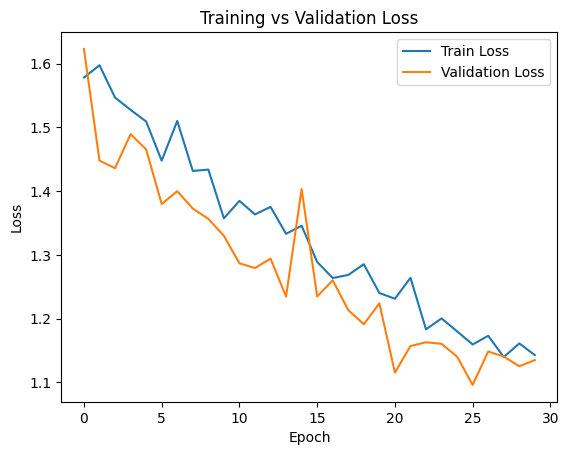

In [ ]:
from matplotlib import pyplot as plt


plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
model.load_state_dict(torch.load("best_model.pth")) # Load the best model
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        loss = loss_function(outputs, y)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

test_loss /= len(test_loader)
accuracy = 100 * correct / total

print("Test Loss:", test_loss)
print("Test Accuracy:", accuracy, "%")

Test Loss: 0.9809539914131165
Test Accuracy: 64.66666666666667 %
